In [1]:
from sympy import *

In [2]:
i, N, a = symbols('i N a', integer=True)
exp = Sum(N - a + 1, (a, 0, N))
print(exp.doit())

-N**2/2 - N/2 + (N + 1)**2


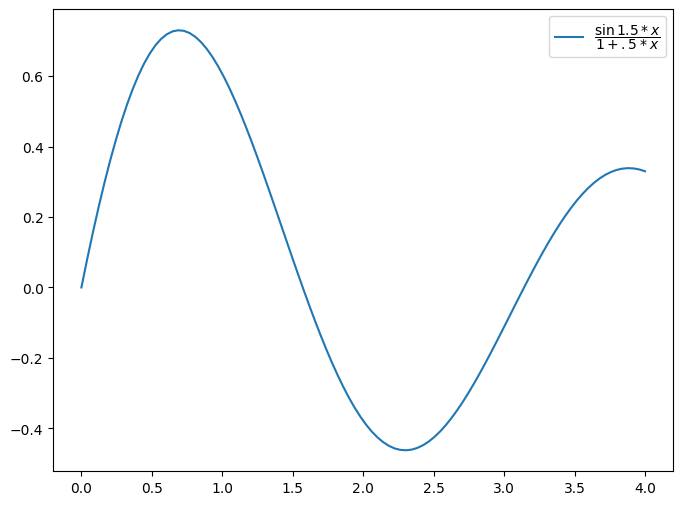

In [3]:
import numpy as np
import matplotlib.pyplot as plt
def FF(x):
    return np.sin(2. * x)/(1+.5*x)
figureSize = (8,6)  # inches
X_max = 4
x_mesh_fine = np.linspace(0, X_max, 100)
FF_values = FF(x_mesh_fine)
plt.figure(figsize=figureSize)
plt.plot(x_mesh_fine, FF_values, label=r'$\dfrac{\sin{1.5*x}}{1+.5*x}$')

plt.legend()
plt.show()

In [4]:
xMesh = np.array([0, .5, .9, 1.25, 2.0, 2.5, 3.0, 3.5, 4])
Fmesh = FF(xMesh)
N = xMesh.size-1
print("Nx=", N)

Nx= 8


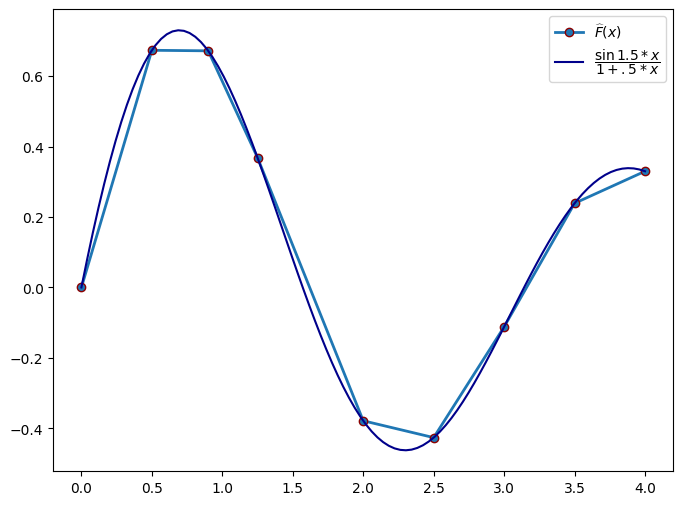

In [5]:
plt.figure(figsize=figureSize)
plt.plot(xMesh, Fmesh, 'o-', label=r'$\widehat{F}(x)$', linewidth=2, markeredgecolor='darkred')
plt.plot(x_mesh_fine, FF_values, label=r'$\dfrac{\sin{1.5*x}}{1+.5*x}$', color='darkblue')
plt.legend()
plt.show()

In [6]:
(xMesh[0], xMesh[N])
s=""
for i in range(2, N+1):
   s += str(i) + ", "
print(s)

2, 3, 4, 5, 6, 7, 8, 


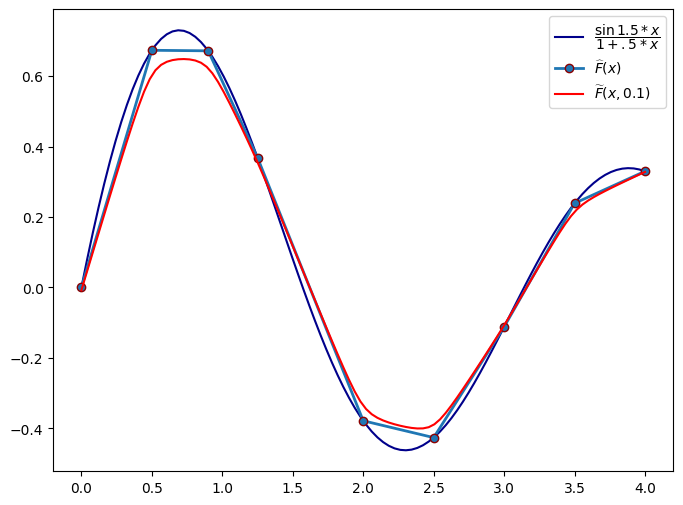

In [7]:
def A(i):
    return (Fmesh[i] - Fmesh[i-1])/(xMesh[i] - xMesh[i-1])

def Fspwl(x, eps):
    return .5*(Fmesh[0] + A(1)*(x - xMesh[0]) + Fmesh[N] + A(N)*(x - xMesh[N]) ) + \
    .5*sum((A(i) - A(i-1))*np.sqrt((x - xMesh[i-1])**2 + eps**2) for i in range(2,N+1))

Fspwl_values = Fspwl(x_mesh_fine, 0.1)
plt.figure(figsize=figureSize)
plt.plot(x_mesh_fine, FF_values, label=r'$\dfrac{\sin{1.5*x}}{1+.5*x}$', color='darkblue')
plt.plot(xMesh, Fmesh, 'o-', label=r'$\widehat{F}(x)$', linewidth=2, markeredgecolor='darkred')
plt.plot(x_mesh_fine, Fspwl_values, label=r'$\widetilde{F}(x, 0.1)$', color='red')
plt.legend()
plt.show()

In [8]:
# F(x,y)
FxyMesh = np.array([[0, -1],[-2,4]])
FxyMesh[1,1]
def Fxy(la,mu):
    return mu*la*(FxyMesh[1,1] - FxyMesh[0,1] - FxyMesh[1,0] + FxyMesh[0,0]) + \
           la*(FxyMesh[1,0] - FxyMesh[0,0]) + mu*(FxyMesh[0,1] - FxyMesh[0,0]) + FxyMesh[0,0]

la = np.linspace(0, 1, 200)
mu = np.linspace(0, 1, 200)
LA, MU = np.meshgrid(la, mu)
FXY = Fxy(LA, MU)
FXY[int(la[0]), int(mu[0])]

0.0

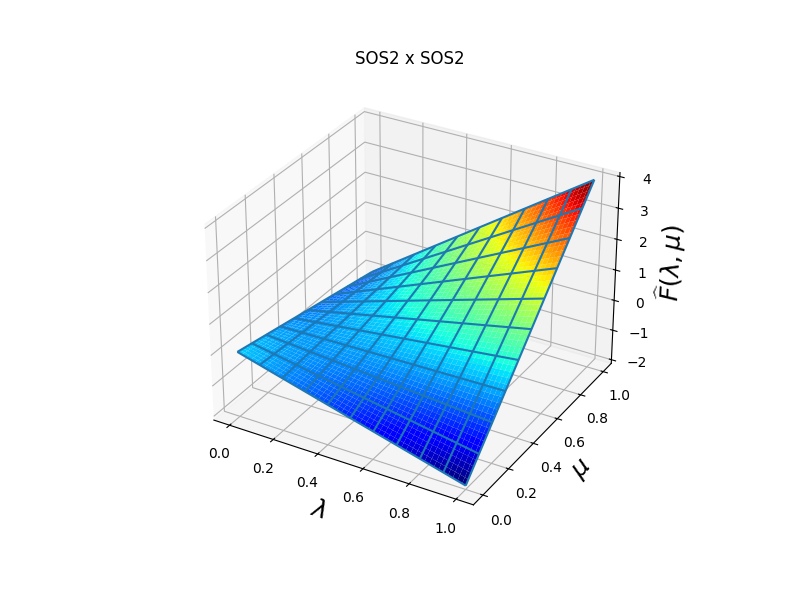

In [9]:
# to interact  with plot
%matplotlib widget

fig = plt.figure(figsize=figureSize)
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(LA, MU, FXY, cmap='jet') # viridis plasma
ax.plot_wireframe(LA, MU, FXY, rstride=20, cstride=20)
ax.set_xlabel(r'$\lambda$', fontsize=18)
ax.set_ylabel(r'$\mu$', fontsize=18)
# ax.set_ylabel(r'$\mu$')
ax.set_zlabel(r'$\widehat{F}(\lambda, \mu)$', fontsize=18)
ax.set_title('SOS2 x SOS2')

plt.show()